# ISTAT Traffic Analysis

-Importazione degli strumenti: Carica le librerie che useremo

-Struttura delle cartelle: Definisce e crea le directory per i file grezzi scaricati e per i dati puliti

In [1]:
# Imports
from pathlib import Path
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_folder_raw = Path("data/raw")
project_folder_clean = Path("data/clean")

# Just to be sure the folders are there, preventing FileNotFoundError
project_folder_raw.mkdir(parents=True, exist_ok=True)
project_folder_clean.mkdir(parents=True, exist_ok=True)

# check
# print("Raw folder:", project_folder_raw)
# print("clean folder:", project_folder_clean)

In [2]:
#ISTAT endpoint, csv conv. and final location
ISTAT_URL = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
HEADERS = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}
ISTAT_path_raw = project_folder_raw / "istat__raw.csv"

try:
    response = requests.get(ISTAT_URL, headers=HEADERS, timeout=20)
    # Erros signaling 
    response.raise_for_status()
    # Save CSV
    ISTAT_path_raw.write_bytes(response.content)
    print("Downloaded ISTAT file:", ISTAT_path_raw)
    print("HTTP status:", response.status_code)
except requests.exceptions.RequestException as e:
    raise RuntimeError("API failed") from e

Downloaded ISTAT file: data\raw\istat__raw.csv
HTTP status: 200


Check and Iinspection of my raw data

In [3]:
# dtype=str typecast
istat_raw = pd.read_csv(ISTAT_path_raw, dtype=str)

# print("Rows:", len(istat_raw))

#inspection
# print("Columns:", list(istat_raw.columns))

# check.
# display(istat_raw.head(15))

istat_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   DATAFLOW          573552 non-null  str  
 1   FREQ              573552 non-null  str  
 2   REF_AREA          573552 non-null  str  
 3   DATA_TYPE         573552 non-null  str  
 4   RESULT            573552 non-null  str  
 5   TIME_PERIOD       573552 non-null  str  
 6   OBS_VALUE         573552 non-null  str  
 7   OBS_STATUS        0 non-null       str  
 8   NOTE_DS           0 non-null       str  
 9   NOTE_REF_AREA     0 non-null       str  
 10  NOTE_DATA_TYPE    0 non-null       str  
 11  NOTE_RESULT       0 non-null       str  
 12  NOTE_TIME_PERIOD  0 non-null       str  
 13  BASE_PER          0 non-null       str  
 14  UNIT_MEAS         0 non-null       str  
 15  UNIT_MULT         0 non-null       str  
dtypes: str(16)
memory usage: 70.0 MB


Accidents

In [4]:
# Incidenti, morti e feriti - comuni
# ROADACC copy
istat_acc = istat_raw[istat_raw["DATA_TYPE"] == "ROADACC"].copy()

#conversion to num (all int)
istat_acc["TIME_PERIOD"] = pd.to_numeric(istat_acc["TIME_PERIOD"])
istat_acc["OBS_VALUE"] = pd.to_numeric(istat_acc["OBS_VALUE"])

# conrolla as_index=False per evitare che diventino il nome della riga"
istat_yearly = istat_acc.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].sum()

# renaming columns
istat_yearly = istat_yearly.rename(columns={"REF_AREA": "area_id", "TIME_PERIOD": "year", "OBS_VALUE": "total_accidents"})


istat_yearly.to_csv(project_folder_clean / "istat_accidents_yearly_simple.csv", index=False)

# check
print("Created:", project_folder_clean / "istat_accidents_yearly_simple.csv")
display(istat_yearly.head(11))




# istat_check = pd.read_csv(project_folder_clean / "istat_accidents_yearly_simple.csv", dtype=str)
# istat_check.info()

Created: data\clean\istat_accidents_yearly_simple.csv


,area_id,year,total_accidents
0,001001,2001,5
1,001001,2002,5
2,001001,2003,4
3,001001,2004,9
4,001001,2005,2
5,001001,2006,1
6,001001,2007,8
7,001001,2008,5
8,001001,2009,4
9,001001,2010,7


Situas

In [5]:
#I'm focusing on the latest years 
latest_year = int(istat_yearly["year"].max())
latest_istat = istat_yearly[istat_yearly["year"] == latest_year].copy()


#Situas
situas_path = project_folder_raw / "situas_territorio.csv"
situas = pd.read_csv(
    situas_path, 
    sep=";", 
    decimal=",", 
    thousands=".", 
    dtype={"Codice Comune (alfanumerico)": str}
)

situas.columns = situas.columns.str.strip().str.upper()

# columns I'm focussing on
cols_to_keep = {
    "CODICE COMUNE (ALFANUMERICO)": "area_id",
    "COMUNE": "city_name", 
    "POPOLAZIONE RESIDENTE": "population",
    "SUPERFICIE (KMQ)": "area_km2"
}

# renaming using cols_to_keep
situas = situas.rename(columns=cols_to_keep)

situas = situas[["area_id", "city_name", "population", "area_km2"]]


# Guarda l'aspetto della colonna chiave nel primo dataset
print("ISTAT area_id format:")
display(latest_istat.head(2))

# Guarda l'aspetto della colonna chiave nel secondo dataset
print("SITUAS area_id format:")
display(situas.head(2))

# Merge
enriched = latest_istat.merge(situas, on="area_id", how="left")
enriched.to_csv(project_folder_clean / "enriched_latest_simple.csv", index=False)

# check
display(enriched.head(11))

ISTAT area_id format:


,area_id,year,total_accidents
23,001001,2024,2
47,001002,2024,5


SITUAS area_id format:


,area_id,city_name,population,area_km2
0,001001,Agliè,2545,13.1462
1,001002,Airasca,3633,15.7393


,area_id,year,total_accidents,city_name,population,area_km2
0,001001,2024,2,Agliè,2545.0,13.1462
1,001002,2024,5,Airasca,3633.0,15.7393
2,001003,2024,1,Ala di Stura,459.0,46.3315
3,001004,2024,4,Albiano d'Ivrea,1638.0,11.7314
4,001006,2024,2,Almese,6355.0,17.8756
5,001008,2024,20,Alpignano,16484.0,11.9193
6,001009,2024,2,Andezeno,2013.0,7.4860
7,001010,2024,1,Andrate,488.0,9.3085
8,001012,2024,1,Arignano,1080.0,8.1668
9,001013,2024,34,Avigliana,12351.0,23.2172


KPI

In [15]:

# Key Performance Indicators KPI

kpi_df = enriched.copy()


#Accidents per 100,000 inhabitants
def calculate_incidence_rate(row):
    population = row["population"]
    total_accidents = row["total_accidents"]
    
    # Perform only if population is a valid positive number
    if population > 0:
        return (total_accidents / population) * 100000
    else:
        return np.nan

# Apply horizontally row by row
kpi_df["accidents_per_100k"] = kpi_df.apply(calculate_incidence_rate, axis=1)



# (Accidents square kilometer)
def calculate_accident_density(row):
    area_size = row["area_km2"]
    total_accidents = row["total_accidents"]
    

    if area_size > 0:
        return total_accidents / area_size
    else:
        return np.nan

kpi_df["accidents_per_km2"] = kpi_df.apply(calculate_accident_density, axis=1)



kpi_df.to_csv(project_folder_clean / "final_kpi_dataset.csv", index=False)

# check
print("Top 5 Municipalities by Accidents per 100k inhabitants:")
display(kpi_df.sort_values(by="accidents_per_100k", ascending=False).head())

Top 5 Municipalities by Accidents per 100k inhabitants:


,area_id,year,total_accidents,city_name,population,area_km2,accidents_per_100k,accidents_per_km2
362,004006,2024,3,Argentera,78.0,76.2591,3846.153846,0.039340
2468,025014,2024,9,Colle Santa Lucia,355.0,15.3388,2535.211268,0.586747
856,010038,2024,5,Montebruno,211.0,17.6787,2369.668246,0.282826
4527,066083,2024,4,Rocca Pia,181.0,44.9610,2209.944751,0.088966
453,004160,2024,4,Paroldo,198.0,12.4249,2020.202020,0.321934


Visual

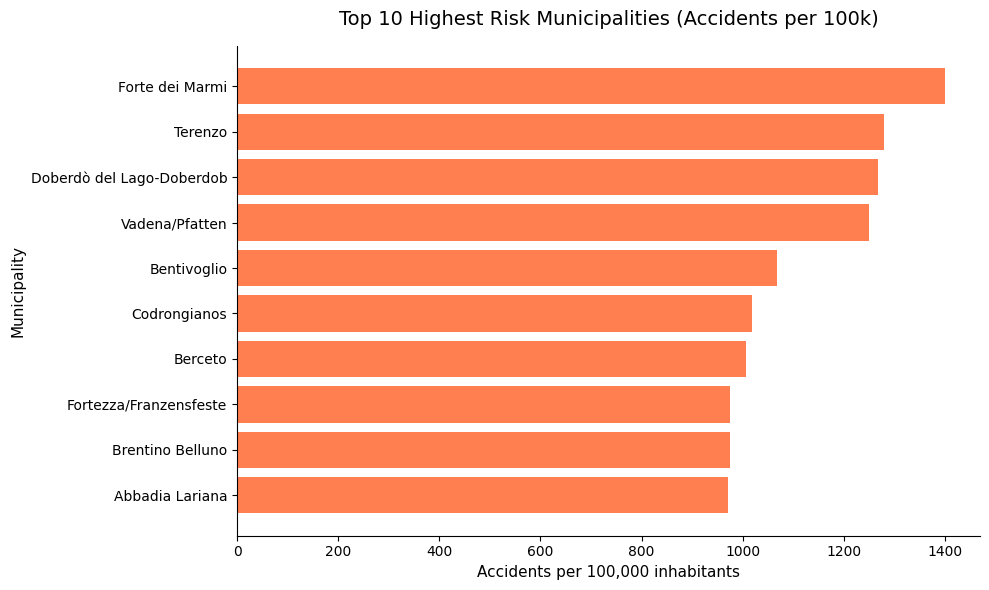

In [ ]:
# Data prep

# Filter < 1000 inhabitants Sort by the highest risk
valid_municipalities = kpi_df[kpi_df["population"] > 1000]
sorted_risk = valid_municipalities.sort_values(by="accidents_per_100k", ascending=False)

# check
top_10_risk = sorted_risk.head(10)

# 2. Chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_10_risk["city_name"][::-1], top_10_risk["accidents_per_100k"][::-1], color='coral')


# Formatting
ax.set_title("Top 10 Highest Risk Municipalities (Accidents per 100k)", fontsize=14, pad=15)
ax.set_xlabel("Accidents per 100,000 inhabitants", fontsize=11)
ax.set_ylabel("Municipality", fontsize=11)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

final

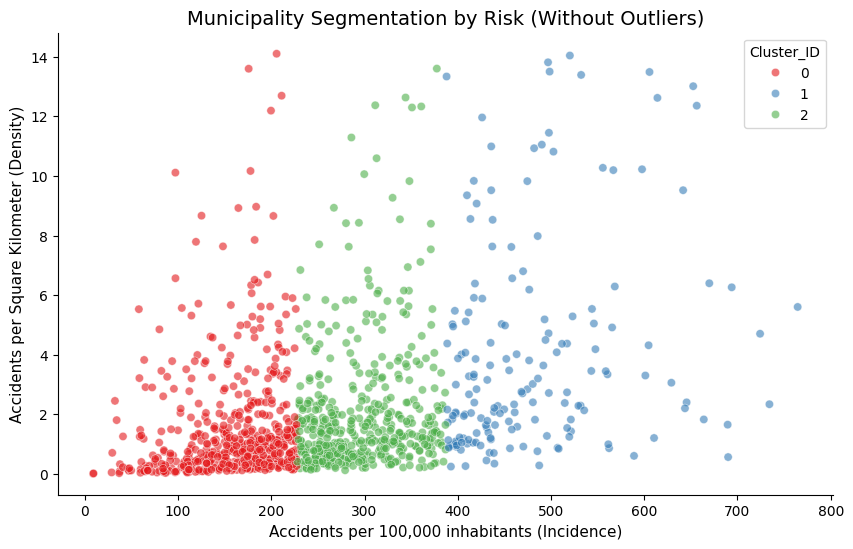

In [ ]:
# Importiamo gli strumenti di Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns


# data preparation and outliers removed in 4 iteration
ml_data = kpi_df.dropna(subset=['accidents_per_100k', 'accidents_per_km2']).copy()
ml_data = ml_data[ml_data['population'] > 10000]
ml_data = ml_data[(ml_data['accidents_per_100k'] < 800) & (ml_data['accidents_per_km2'] < 15)]


# K-Means model (Low, Medium, High)
kmeans = KMeans(n_clusters=3, random_state=70, n_init=17)

# Apply the model directly to the raw KPI features
ml_data['Cluster_ID'] = kmeans.fit_predict(
    ml_data[['accidents_per_100k', 'accidents_per_km2']]
)

# Scatter Plot

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=ml_data,
    x='accidents_per_100k',
    y='accidents_per_km2',
    hue='Cluster_ID',
    palette='Set1',
    alpha=0.6
)

#labels
plt.title('Municipality Segmentation by Risk (Without Outliers)', fontsize=14)
plt.xlabel('Accidents per 100,000 inhabitants (Incidence)', fontsize=11)
plt.ylabel('Accidents per Square Kilometer (Density)', fontsize=11)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)



ml_data.to_csv(project_folder_clean / "final_clustered_data.csv", index=False)


plt.show()